In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [2]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


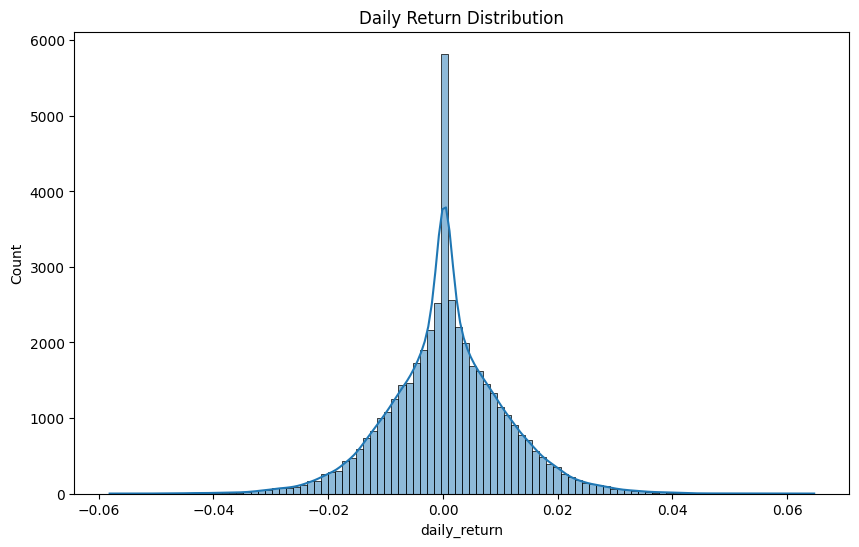

In [3]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=100,
    kde=True
)

plt.title("Daily Return Distribution")
plt.show()

In [4]:
def calculate_cagr(start_nav,end_nav,years):

    return ((end_nav/start_nav)**(1/years)-1)*100
cagr_results = []

for fund in nav["amfi_code"].unique():

    df = nav[
        nav["amfi_code"] == fund
    ].sort_values("date")

    start_nav = df.iloc[0]["nav"]
    end_nav = df.iloc[-1]["nav"]

    years = (
        (df.iloc[-1]["date"] -
         df.iloc[0]["date"]).days
    ) / 365

    cagr = calculate_cagr(
        start_nav,
        end_nav,
        years
    )

    cagr_results.append(
        [fund,cagr]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        "amfi_code",
        "cagr_pct"
    ]
)

cagr_df.head()

,amfi_code,cagr_pct
0,100016,2.635246
1,100025,4.455091
2,100033,30.099704
3,101206,23.520489
4,101207,7.933121


In [5]:
rf = 0.065

sharpe_list = []

for fund in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == fund
    ]["daily_return"].dropna()

    annual_return = (
        returns.mean()*252
    )

    annual_vol = (
        returns.std()*np.sqrt(252)
    )

    sharpe = (
        annual_return-rf
    ) / annual_vol

    sharpe_list.append(
        [fund,sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head()

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


In [6]:
sortino_list = []

for fund in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == fund
    ]["daily_return"].dropna()

    downside = returns[
        returns < 0
    ]

    downside_std = (
        downside.std()
        * np.sqrt(252)
    )

    annual_return = (
        returns.mean()*252
    )

    sortino = (
        annual_return-rf
    ) / downside_std

    sortino_list.append(
        [fund,sortino]
    )

sortino_df = pd.DataFrame(
    sortino_list,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

In [8]:
alpha_beta = []

nifty = benchmark[
    benchmark["index_name"]=="NIFTY 100"
]

for fund in nav["amfi_code"].unique():

    fund_df = nav[
        nav["amfi_code"]==fund
    ]

    merged = pd.merge(
        fund_df,
        nifty,
        on="date"
    )

    merged["benchmark_return"] = (
        merged["close_value"]
        .pct_change()
    )

    merged = merged.dropna()
    if len(merged) < 2:
        continue

    beta,alpha,r,p,std = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha = alpha*252

    alpha_beta.append(
        [fund,alpha,beta]
    )

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

In [9]:
drawdowns = []

for fund in nav["amfi_code"].unique():

    df = nav[
        nav["amfi_code"]==fund
    ]

    running_max = (
        df["nav"].cummax()
    )

    drawdown = (
        df["nav"]/running_max
    ) - 1

    max_dd = drawdown.min()

    drawdowns.append(
        [fund,max_dd]
    )

dd_df = pd.DataFrame(
    drawdowns,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

In [10]:
scorecard = (
    cagr_df
    .merge(sharpe_df)
    .merge(alpha_beta_df)
    .merge(dd_df)
)

scorecard["score"] = (
      scorecard["cagr_pct"].rank(pct=True)*30
    + scorecard["sharpe_ratio"].rank(pct=True)*25
    + scorecard["alpha"].rank(pct=True)*20
    + scorecard["max_drawdown"].rank(
        ascending=False,
        pct=True
      )*10
)

scorecard["score"] = (
    scorecard["score"]
    / scorecard["score"].max()
    *100
)

scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)